<img src="images/Labs/III/i.jpeg" alt="scheme" height=70% width=80%>


По сравнению с Contrastive Loss, ArcFace имеет несколько преимуществ.

ArcFace не требует определения порога для различения положительных и отрицательных пар, что упрощает реализацию.

ArcFace явно изучает дискриминационные угловые отношения между классами, что приводит к улучшению межклассовлму разделению.

В Contrastive Loss наблюдается комбинаторный взрыв количества пар лиц, особенно для крупномасштабных наборов данных, что приводит к значительному увеличению количества шагов обучения.

Обучение ArcFace можно проводить без анализа выборки.

ArcFace показал превосходную производительность в крупномасштабных задачах идентификации лиц, где количество идентификаторов огромно.

<img src="images/Labs/III/angle_loss.png" alt="scheme" height=60% width=60%>

<img src="images/Labs/III/SoftmaxArcface.png" alt="scheme" height=50% width=50%>

### ArcFace Loss

<img src="images/Labs/III/Loss.png" alt="scheme" height=70% width=70%>

where **S** is the scaling factor,

**m** is the angular margin (m ~ 28.6),

**theta** is the angle between the feature and the weight vector of the ground truth class, and 

**theta_j** is the angle between the feature and the weight vector of all other classes.

<img src="images/Labs/III/arcface.jpg" alt="scheme" height=90% width=90%>

In [ ]:
# final_layer:

class CosineComponent(nn.Module):
    
    def __init__(self, emb_size, output_classes):
        super().__init__()
        self.W = nn.Parameter(torch.Tensor(emb_size, output_classes))
        nn.init.kaiming_uniform_(self.W)

    def forward(self, x):
        # Step 1:
        x_norm = F.normalize(x)
        W_norm = F.normalize(self.W, dim=0)
        # Step 2:
        return x_norm @ W_norm

In [ ]:
def arcface_loss(cosine, target, m=.4):
    # this prevents nan when a value slightly crosses 1.0 due to numerical error
    cosine = cosine.clip(-1+1e-7, 1-1e-7) 
    # Step 3:
    arcosine = cosine.arccos()
    # Step 4:
    arcosine += F.one_hot(target, num_classes = output_classes) * m
    # Step 5:
    cosine2 = arcosine.cos()
    # Step 6:
    return F.cross_entropy(cosine2, target)

### Reformulate the cross-entropy loss

<img src="images/Labs/III/CELoss.png" alt="scheme" height=50% width=50%>

<img src="images/Labs/III/CE_Arc.png" alt="scheme" height=50% width=50%>

https://arxiv.org/pdf/1801.07698

In [1]:
!pip install pytorch-metric-learning

https://kevinmusgrave.github.io/pytorch-metric-learning/losses/#arcfaceloss

Example

https://github.com/KevinMusgrave/pytorch-metric-learning/blob/master/examples/notebooks/SubCenterArcFaceMNIST.ipynb

### Задание

1) датасет:
/mnt/data/EuroSAT_MS
внутри папки AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, residential, River, SeaLake

2) Используя ArcFace Loss обучить нейронку кодировать изображения одного класса похожим образом (всего 10 классов ~3000 изображений на класс)

3) С помощью t-SNE визуализировать результаты работы (использовать тестовый датасет)

4) Визуализировать результаты работы (inference) в виде - пара изображений + distance

#### Dataset

https://github.com/phelber/EuroSAT?tab=readme-ov-file

Epoch [1/25] Average Loss: 0.8806
Epoch [5/25] Average Loss: 0.2769
Epoch [10/25] Average Loss: 0.1357
Epoch [15/25] Average Loss: 0.0406
Epoch [20/25] Average Loss: 0.0089
Epoch [25/25] Average Loss: 0.0017


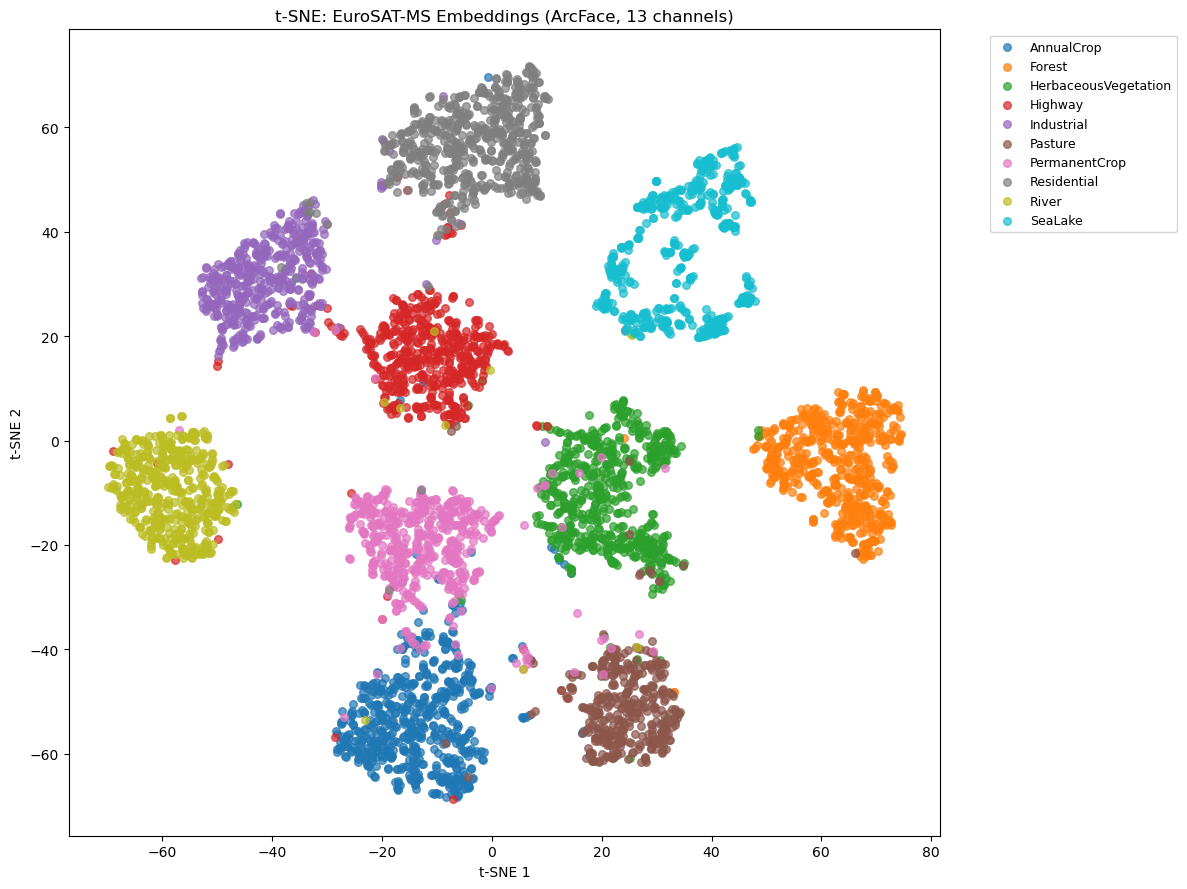

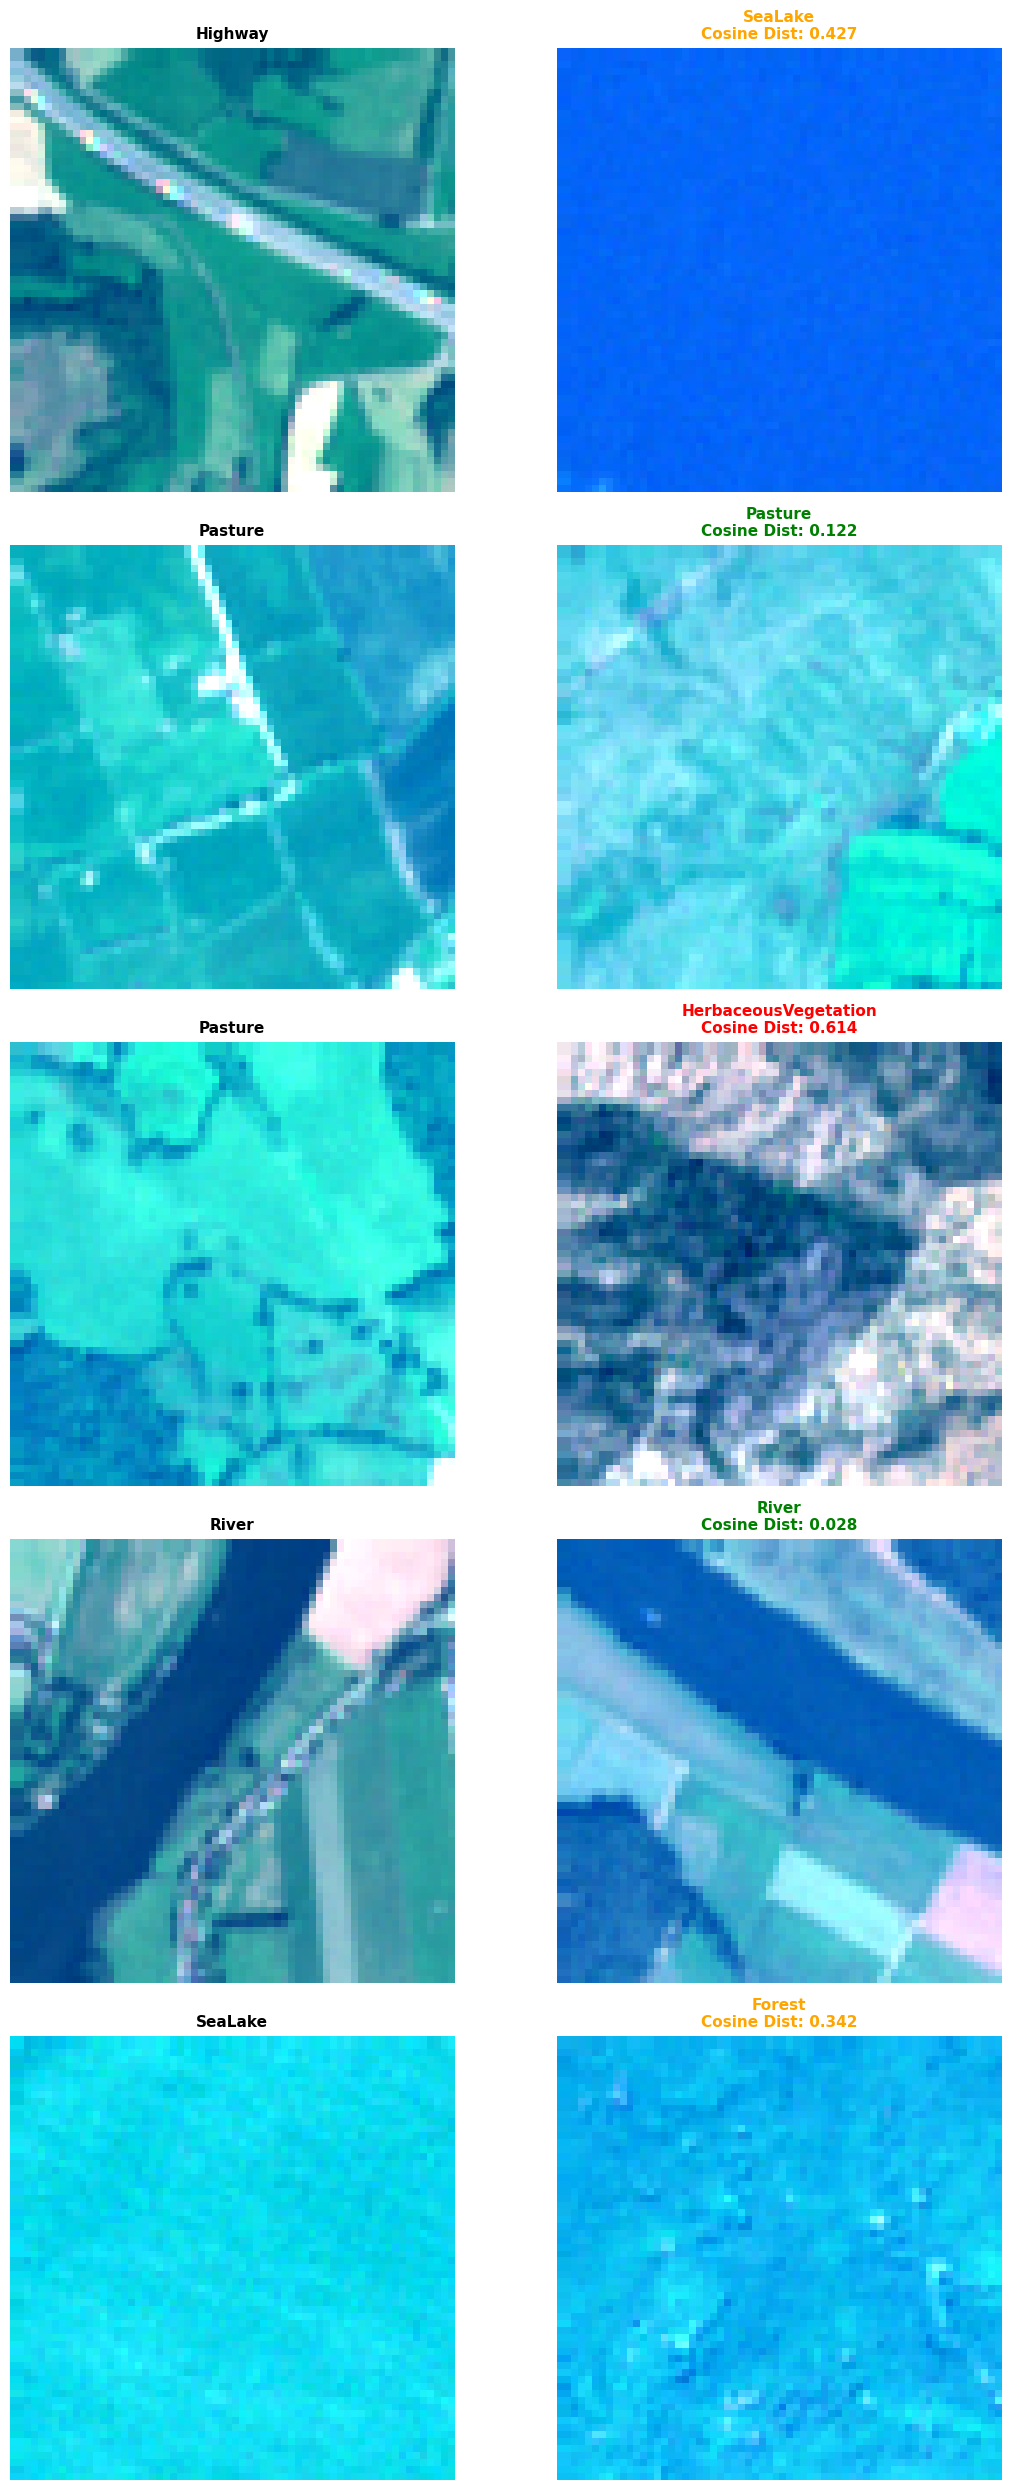

In [2]:
import os
import random
import tifffile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from pytorch_metric_learning import losses
from pytorch_metric_learning.losses import ArcFaceLoss
from torchvision import models
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

DATA_DIR = "/mnt/data/EuroSAT_MS"  
EMBEDDING_DIM = 128
NUM_CLASSES = 10
IN_CHANNELS = 13  
IMG_SIZE = 64
BATCH_SIZE = 32 
EPOCHS = 25
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED) 
np.random.seed(SEED)  
random.seed(SEED)


class EuroSAT_MSDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root = root_dir
        self.transform = transform
        self.channels = IN_CHANNELS
        self.img_size = IMG_SIZE

        self.classes = sorted(
            [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        )
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        # Собираем список путь лейбл
        self.samples = []
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".tif", ".tiff")):
                    self.samples.append(
                        (os.path.join(cls_dir, fname), self.class_to_idx[cls_name])
                    )


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        # Загрузка TIFF
        img = tifffile.imread(path)  

        # Приведение к (C, H, W)
        if img.shape[-1] == self.channels:
            img = np.moveaxis(img, -1, 0)
        elif img.shape[0] != self.channels:
            raise ValueError(f"Неожиданная форма {img.shape} в {path}")

        # Конвертация в torch.Tensor
        img_tensor = torch.from_numpy(img).float()

        # Нормализация 
        img_tensor = img_tensor / 65535.0
        img_tensor = torch.clamp(img_tensor, 0.0, 1.0)

        # Аугментации
        if self.transform is not None:
            img_tensor = self.transform(img_tensor)

        return img_tensor, label


class TensorAugmentations:

    def __init__(self, training=True, p_flip=0.5, p_rot=0.5, p_brightness=0.3):
        self.training = training
        self.p_flip = p_flip
        self.p_rot = p_rot
        self.p_brightness = p_brightness

    def __call__(self, x):
        if not self.training:
            return x

        if random.random() < self.p_flip:
            x = torch.flip(x, dims=[2])
        if random.random() < self.p_flip:
            x = torch.flip(x, dims=[1])
        if random.random() < self.p_rot:
            k = random.randint(0, 3)
            if k > 0:
                x = torch.rot90(x, k=k, dims=[1, 2])
        if random.random() < self.p_brightness:
            factor = random.uniform(0.8, 1.2)
            x = torch.clamp(x * factor, 0.0, 1.0)
        if random.random() < 0.3:
            noise = torch.randn_like(x) * 0.01
            x = torch.clamp(x + noise, 0.0, 1.0)

        return x


class EmbeddingNet(nn.Module):
    def __init__(self, emb_dim=EMBEDDING_DIM, in_channels=IN_CHANNELS):
        super().__init__()
        resnet = models.resnet18(weights=None)
        resnet.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )
        # Удаляем последний fully connected слой
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        # Новый слой для эмбеддингов
        self.fc = nn.Linear(resnet.fc.in_features, emb_dim)

    def forward(self, x):
        x = self.backbone(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        # pytorch-metric-learning ArcFace сам делает L2 нормализацию
        # return F.normalize(x, p=2, dim=1) # Не нормализуем здесь
        return x # Возвращаем не нормализованные эмбеддинги


full_dataset = EuroSAT_MSDataset(DATA_DIR, transform=TensorAugmentations(training=True))
class_names = full_dataset.classes

train_size = int(len(full_dataset) * 0.8)
test_size = len(full_dataset) - train_size
train_ds, test_ds = random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(SEED),
)

test_ds.dataset.transform = TensorAugmentations(training=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

model = EmbeddingNet(emb_dim=EMBEDDING_DIM, in_channels=IN_CHANNELS).to(DEVICE)

# Инициализация ArcFace Loss из pytorch-metric-learning
# s - масштаб, m - маржин
loss_fn = ArcFaceLoss(num_classes=NUM_CLASSES, embedding_size=EMBEDDING_DIM, margin=0.5, scale=30)

# Оптимизатор
loss_func = losses.ArcFaceLoss(num_classes=10, embedding_size=128).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
loss_optimizer = torch.optim.Adam(loss_func.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, labels) in enumerate(train_loader):
        data, labels = data.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        # Forward pass - получаем эмбеддинги
        embeddings = model(data)

        # Подаем эмбеддинги и метки в loss
        loss = loss_fn(embeddings, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        # Для ArcFace точность на каждом батче может быть не репрезентативной,
        # так как она зависит от масштаба и маржина в loss.
        # Но можно попробовать получить предсказания из весов классификатора loss_fn
        # В pytorch-metric-learning веса классификатора находятся внутри loss_fn.sub_losses["arcface"]
        # Это может быть немного сложнее, чем вручную вычислять косинус.
        # Пока просто логируем loss
        # preds = ... (не тривиально с текущим интерфейсом)
        total += labels.size(0)
        correct_batch = 0

    scheduler.step()
    avg_loss = running_loss / len(train_loader)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Average Loss: {avg_loss:.4f}")


model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(DEVICE)
        embeddings = model(data)
        # L2 нормализацию
        normalized_embeddings = F.normalize(embeddings, p=2, dim=1)
        all_embeddings.append(normalized_embeddings.cpu().numpy())
        all_labels.append(labels.numpy())

embeddings_np = np.vstack(all_embeddings)  # [N_test, 128]
labels_np = np.concatenate(all_labels)  # [N_test]

def visualize_tsne(embeddings, labels, class_names):
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, init="pca", random_state=SEED, verbose=0)
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(12, 9))
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))

    for i, cls_name in enumerate(class_names):
        mask = labels == i
        plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=[colors[i]], label=cls_name, s=30, alpha=0.7)

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    plt.title("t-SNE: EuroSAT-MS Embeddings (ArcFace, 13 channels)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

visualize_tsne(embeddings_np, labels_np, class_names)

def visualize_pairs(dataset, embeddings, labels, class_names, n_pairs=5):
    fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 5 * n_pairs))
    if n_pairs == 1:
        axes = axes.reshape(1, -1)

    np.random.seed(SEED)

    def tensor_to_display(img_tensor):
        rgb = img_tensor[[3, 2, 1], :, :].cpu().numpy()
        rgb = np.moveaxis(rgb, 0, -1)
        # Растяжение контраста
        p_low, p_high = np.percentile(rgb, (2, 98))
        rgb_stretched = np.clip((rgb - p_low) / (p_high - p_low + 1e-6), 0.0, 1.0)
        return (rgb_stretched * 255).astype(np.uint8)

    if hasattr(test_ds, 'indices'):
        indices = test_ds.indices
    else:
        # Если random_split не создал indices предполагаем что это весь датасет
        indices = list(range(len(test_ds.dataset)))
    
    for k in range(n_pairs):
        if np.random.rand() > 0.5:
            # Same class
            cls = np.random.choice(np.unique(labels))
            idxs_in_batch = np.where(labels == cls)[0]
            if len(idxs_in_batch) < 2:
                i, j = np.random.choice(len(labels), 2, replace=False)
            else:
                i_idx, j_idx = np.random.choice(idxs_in_batch, 2, replace=False)
                # Получаем реальный индекс в исходном датасете
                i_real = indices[i_idx]
                j_real = indices[j_idx]
                i_emb_idx = i_idx 
                j_emb_idx = j_idx 
        else:
            # Different classes
            cls1, cls2 = np.random.choice(np.unique(labels), 2, replace=False)
            i_idx = np.random.choice(np.where(labels == cls1)[0])
            j_idx = np.random.choice(np.where(labels == cls2)[0])
            i_real = indices[i_idx]
            j_real = indices[j_idx]
            i_emb_idx = i_idx
            j_emb_idx = j_idx

        img1, lbl1 = dataset.dataset[i_real] 
        img2, lbl2 = dataset.dataset[j_real]

        emb1 = embeddings[i_emb_idx]
        emb2 = embeddings[j_emb_idx]

        # Косинусное расстояние
        cos_sim = np.dot(emb1, emb2)  # L2 
        cos_dist = 1.0 - cos_sim

        axes[k, 0].imshow(tensor_to_display(img1))
        axes[k, 0].set_title(f"{class_names[lbl1]}", fontsize=11, fontweight="bold")
        axes[k, 0].axis("off")

        axes[k, 1].imshow(tensor_to_display(img2))
        title = f"{class_names[lbl2]}\nCosine Dist: {cos_dist:.3f}"
        color = "green" if cos_dist < 0.3 else ("orange" if cos_dist < 0.6 else "red")
        axes[k, 1].set_title(title, fontsize=11, fontweight="bold", color=color)
        axes[k, 1].axis("off")

    plt.tight_layout()
    plt.show()

visualize_pairs(test_ds, embeddings_np, labels_np, class_names, n_pairs=5)

Epoch [1/25] Average Loss: 1.0226
Epoch [5/25] Average Loss: 0.3509
Epoch [10/25] Average Loss: 0.2250
Epoch [15/25] Average Loss: 0.1344
Epoch [20/25] Average Loss: 0.0823
Epoch [25/25] Average Loss: 0.0565
✅ Форма матрицы ArcFace: (10, 128)


/tmp/ipykernel_15967/235194230.py:272: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


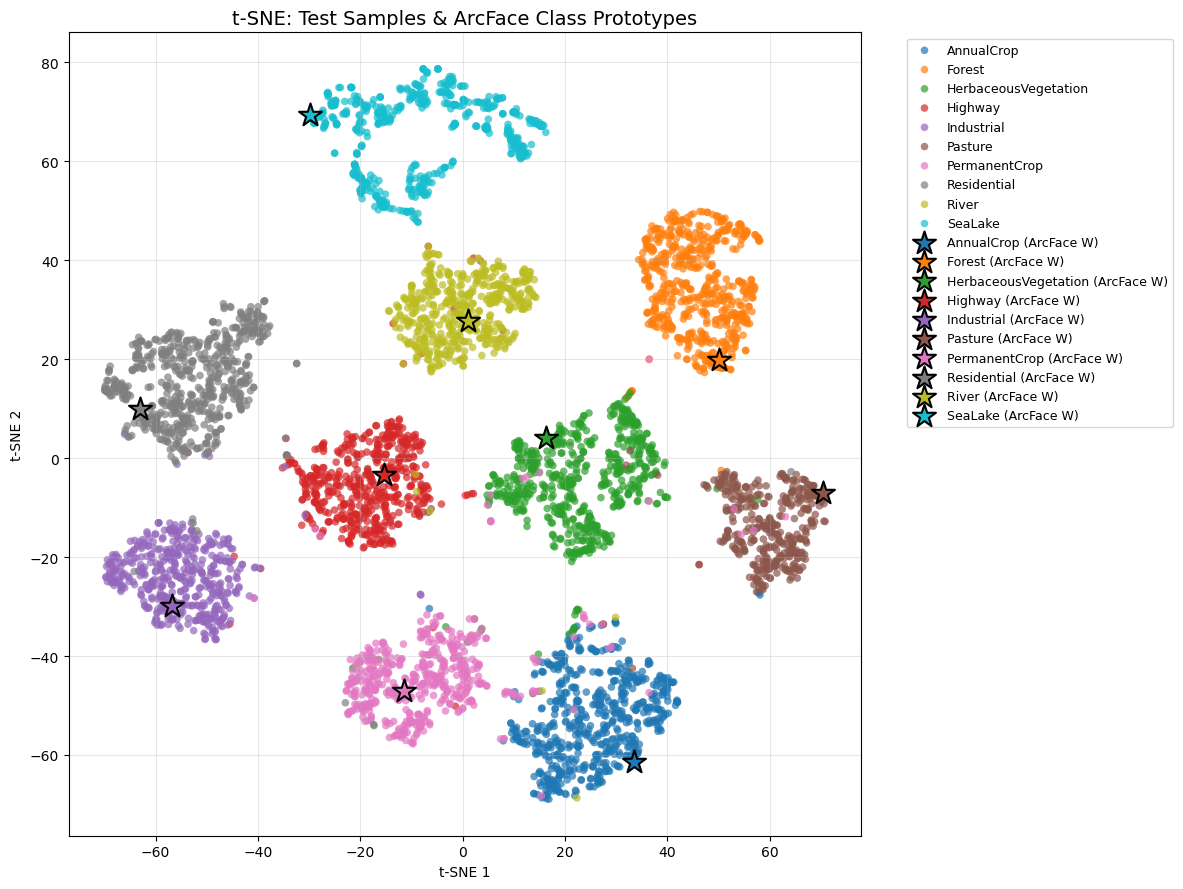

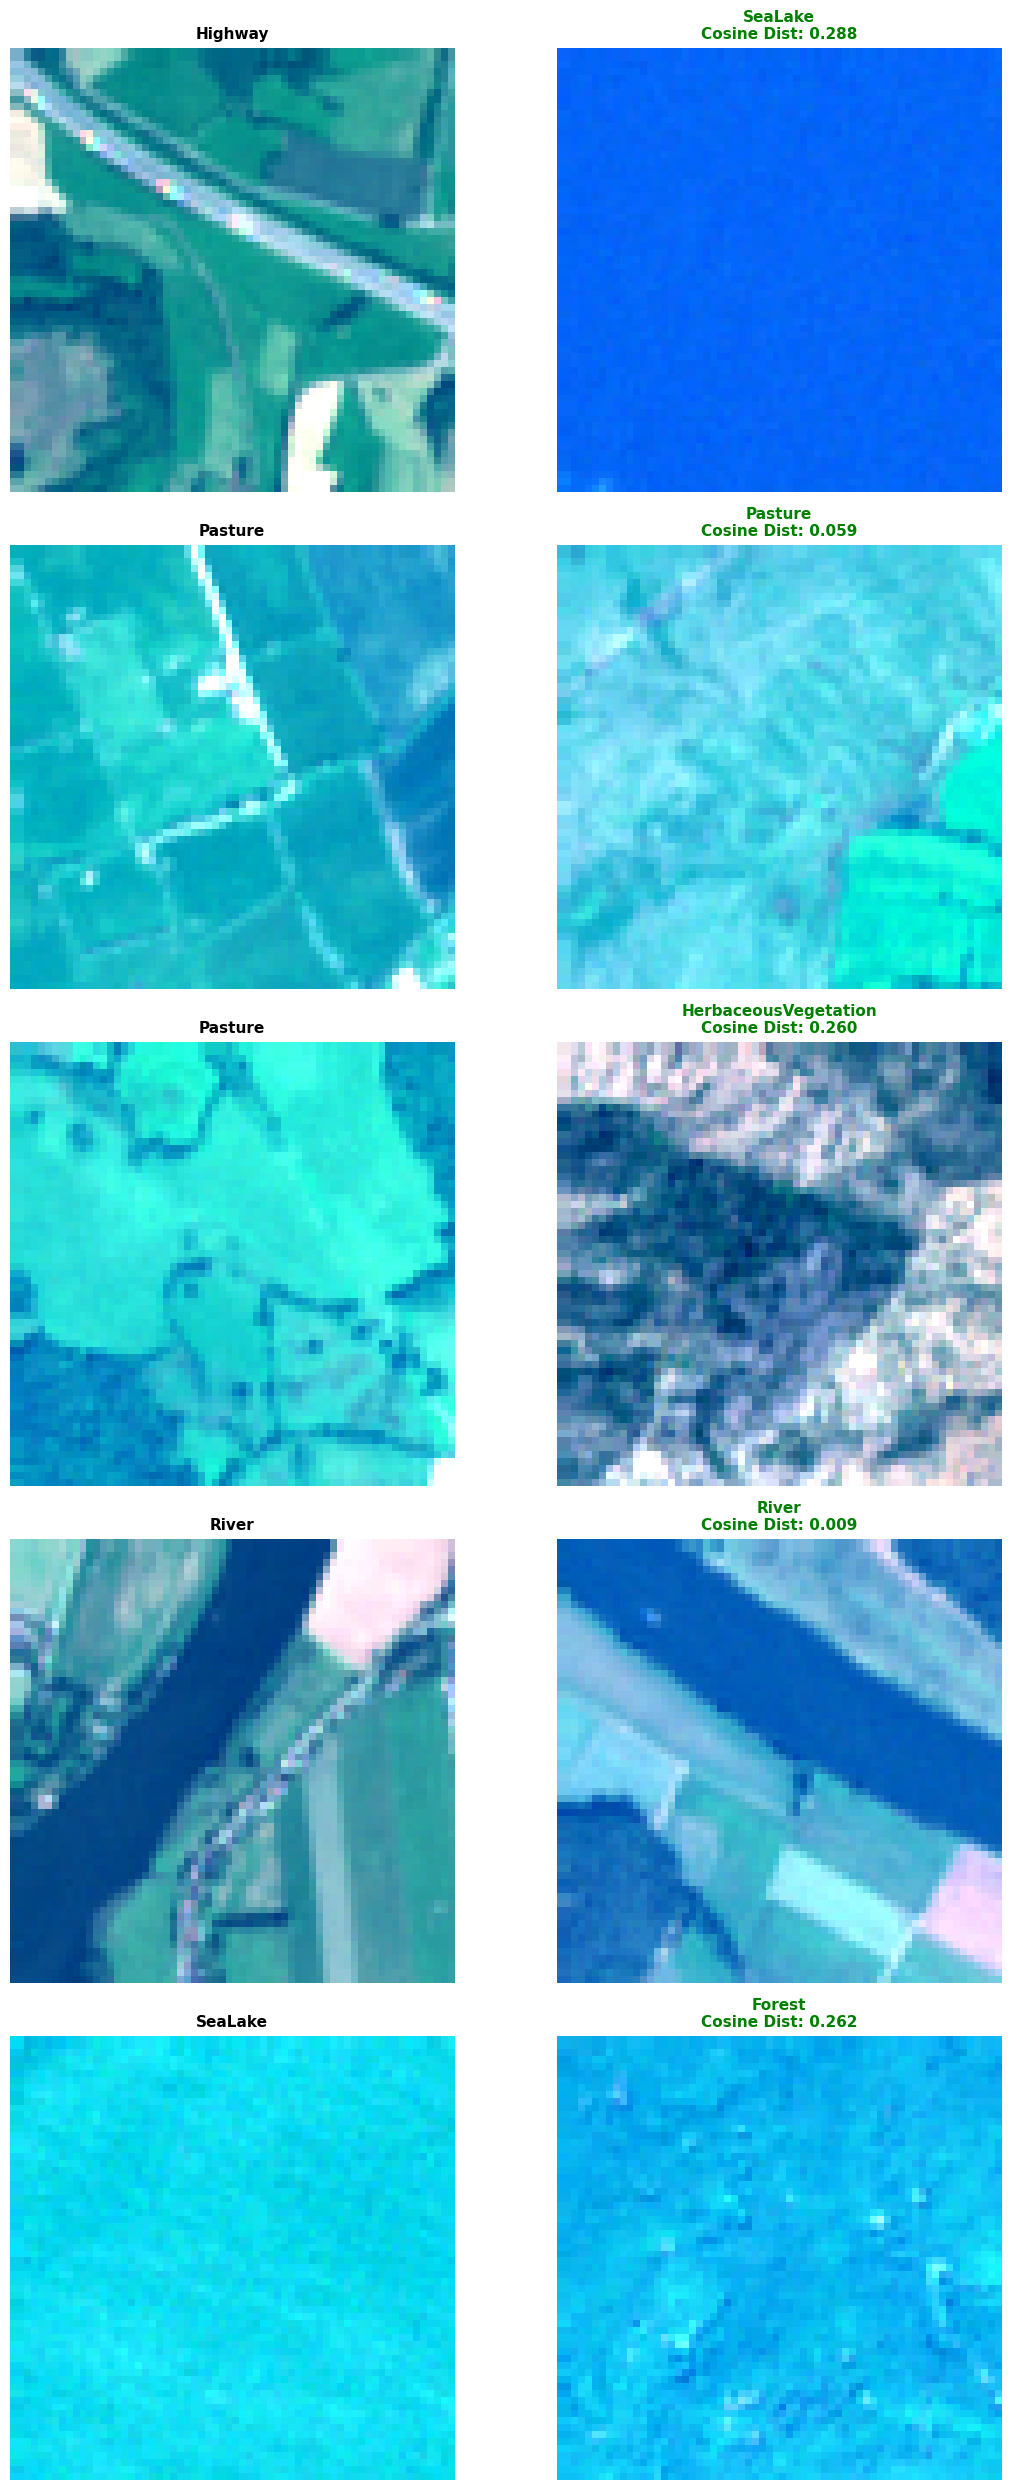

In [2]:
import os
import random
import tifffile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from pytorch_metric_learning.losses import ArcFaceLoss
from torchvision import models
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ========================
# КОНФИГУРАЦИЯ
# ========================
DATA_DIR = "/mnt/data/EuroSAT_MS"
EMBEDDING_DIM = 128
NUM_CLASSES = 10
IN_CHANNELS = 13
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


class EuroSAT_MSDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = root_dir
        self.transform = transform
        self.channels = IN_CHANNELS

        self.classes = sorted(
            [
                d
                for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ]
        )
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        self.samples = []
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".tif", ".tiff")):
                    self.samples.append(
                        (os.path.join(cls_dir, fname), self.class_to_idx[cls_name])
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = tifffile.imread(path)

        if img.shape[-1] == self.channels:
            img = np.moveaxis(img, -1, 0)
        elif img.shape[0] != self.channels:
            raise ValueError(f"Неожиданная форма {img.shape} в {path}")

        img_tensor = torch.from_numpy(img).float()
        img_tensor = img_tensor / 65535.0
        img_tensor = torch.clamp(img_tensor, 0.0, 1.0)

        if self.transform is not None:
            img_tensor = self.transform(img_tensor)

        return img_tensor, label


class TensorAugmentations:
    def __init__(self, training=True, p_flip=0.5, p_rot=0.5, p_brightness=0.3):
        self.training = training
        self.p_flip = p_flip
        self.p_rot = p_rot
        self.p_brightness = p_brightness

    def __call__(self, x):
        if not self.training:
            return x
        if random.random() < self.p_flip:
            x = torch.flip(x, dims=[2])
        if random.random() < self.p_flip:
            x = torch.flip(x, dims=[1])
        if random.random() < self.p_rot:
            k = random.randint(0, 3)
            if k > 0:
                x = torch.rot90(x, k=k, dims=[1, 2])
        if random.random() < self.p_brightness:
            factor = random.uniform(0.8, 1.2)
            x = torch.clamp(x * factor, 0.0, 1.0)
        if random.random() < 0.3:
            noise = torch.randn_like(x) * 0.01
            x = torch.clamp(x + noise, 0.0, 1.0)
        return x


class EmbeddingNet(nn.Module):
    def __init__(self, emb_dim=EMBEDDING_DIM, in_channels=IN_CHANNELS):
        super().__init__()
        resnet = models.resnet18(weights=None)
        resnet.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.fc = nn.Linear(resnet.fc.in_features, emb_dim)

    def forward(self, x):
        x = self.backbone(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


base_dataset = EuroSAT_MSDataset(DATA_DIR, transform=None)
class_names = base_dataset.classes

train_size = int(len(base_dataset) * 0.8)
test_size = len(base_dataset) - train_size
train_subset, test_subset = random_split(
    base_dataset, [train_size, test_size], generator=torch.Generator().manual_seed(SEED)
)


class TransformWrapper(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label


train_ds = TransformWrapper(train_subset, TensorAugmentations(training=True))
test_ds = TransformWrapper(test_subset, TensorAugmentations(training=False))

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)


model = EmbeddingNet(emb_dim=EMBEDDING_DIM, in_channels=IN_CHANNELS).to(DEVICE)
loss_fn = ArcFaceLoss(
    num_classes=NUM_CLASSES, embedding_size=EMBEDDING_DIM, margin=0.5, scale=30
).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for batch_idx, (data, labels) in enumerate(train_loader):
        data, labels = data.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        embeddings = model(data)
        loss = loss_fn(embeddings, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1}/{EPOCHS}] Average Loss: {running_loss / len(train_loader):.4f}"
        )


model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(DEVICE)
        embeddings = model(data)
        all_embeddings.append(F.normalize(embeddings, p=2, dim=1).cpu().numpy())
        all_labels.append(labels.numpy())

embeddings_np = np.vstack(all_embeddings)
labels_np = np.concatenate(all_labels)

#  Безопасное извлечение матрицы весов ArcFace
weight_matrix = None
if hasattr(loss_fn, "classifier") and hasattr(loss_fn.classifier, "weight"):
    weight_matrix = loss_fn.classifier.weight.data
elif hasattr(loss_fn, "W"):
    weight_matrix = loss_fn.W.data
else:
    weight_matrix = next(loss_fn.parameters()).data

arcface_weights = weight_matrix.cpu().numpy()

# Автоматическая корректировка формы (ожидается 10 x 128)
if arcface_weights.shape == (EMBEDDING_DIM, NUM_CLASSES):
    arcface_weights = arcface_weights.T

print(f" Форма матрицы ArcFace: {arcface_weights.shape}")

#  Объединение и визуализация
combined_embeddings = np.vstack([embeddings_np, arcface_weights])
combined_labels = np.concatenate([labels_np, np.arange(NUM_CLASSES)])
is_prototype = np.zeros(combined_embeddings.shape[0], dtype=bool)
is_prototype[-NUM_CLASSES:] = True

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    init="pca",
    random_state=SEED,
    verbose=0,
)
emb_2d = tsne.fit_transform(combined_embeddings)


def visualize_tsne_with_prototypes(embeddings_2d, labels, class_names, is_proto):
    plt.figure(figsize=(12, 9))
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))

    for i, cls_name in enumerate(class_names):
        mask = (labels == i) & (~is_proto)
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[colors[i]],
            label=cls_name,
            s=30,
            alpha=0.7,
            edgecolors="none",
        )

    for i, cls_name in enumerate(class_names):
        mask = (labels == i) & is_proto
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=colors[i],
            marker="*",
            s=300,
            edgecolors="black",
            linewidths=1.5,
            zorder=5,
            label=f"{cls_name} (ArcFace W)",
        )

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    plt.title("t-SNE: Test Samples & ArcFace Class Prototypes", fontsize=14)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


visualize_tsne_with_prototypes(emb_2d, combined_labels, class_names, is_prototype)

def visualize_pairs(dataset, embeddings, labels, class_names, n_pairs=5):
    fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 5 * n_pairs))
    if n_pairs == 1:
        axes = axes.reshape(1, -1)
    np.random.seed(SEED)
    unique_labels = np.unique(labels)

    def tensor_to_display(img_tensor):
        rgb = img_tensor[[3, 2, 1], :, :].cpu().numpy()
        rgb = np.moveaxis(rgb, 0, -1)
        p_low, p_high = np.percentile(rgb, (2, 98))
        rgb_stretched = np.clip((rgb - p_low) / (p_high - p_low + 1e-6), 0.0, 1.0)
        return (rgb_stretched * 255).astype(np.uint8)

    for k in range(n_pairs):
        if np.random.rand() > 0.5:
            cls = np.random.choice(unique_labels)
            idxs = np.where(labels == cls)[0]
            i, j = (
                np.random.choice(idxs, 2, replace=False)
                if len(idxs) >= 2
                else np.random.choice(len(labels), 2, replace=False)
            )
        else:
            cls1, cls2 = np.random.choice(unique_labels, 2, replace=False)
            i = np.random.choice(np.where(labels == cls1)[0])
            j = np.random.choice(np.where(labels == cls2)[0])

        img1, lbl1 = dataset[i]
        img2, lbl2 = dataset[j]
        cos_sim = np.dot(embeddings[i], embeddings[j])
        cos_dist = 1.0 - cos_sim

        axes[k, 0].imshow(tensor_to_display(img1))
        axes[k, 0].set_title(f"{class_names[lbl1]}", fontsize=11, fontweight="bold")
        axes[k, 0].axis("off")

        axes[k, 1].imshow(tensor_to_display(img2))
        title = f"{class_names[lbl2]}\nCosine Dist: {cos_dist:.3f}"
        color = "green" if cos_dist < 0.3 else ("orange" if cos_dist < 0.6 else "red")
        axes[k, 1].set_title(title, fontsize=11, fontweight="bold", color=color)
        axes[k, 1].axis("off")

    plt.tight_layout()
    plt.show()


visualize_pairs(test_ds, embeddings_np, labels_np, class_names, n_pairs=5)